# Pipeline HerbalScan — Klasifikasi Daun Herbal

Notebook ini menjalankan seluruh pipeline:
1. Remove background (rembg)
2. Resize 224×224
3. Augmentasi Flip (H + V) + Rotasi
4. Build dataset final (no-bg & bg)
5. Visualisasi sampel
6. **Eksperimen 1** — Gabungan BG + NoBG, **daun sehat saja** (16 kelas), split 80:20 & 70:30
7. **Eksperimen 2** — Gabungan BG + NoBG, **semua kondisi termasuk rusak** (32 kelas), split 80:20 & 70:30
8. Ringkasan hasil

**Struktur kelas**:
- Eksperimen 1: `"Daun X NoBG"` dan `"Daun X BG"` → 8 spesies × 2 = 16 kelas
- Eksperimen 2: `"Daun X NoBG"`, `"Daun X BG"`, `"Daun X Rusak NoBG"`, `"Daun X Rusak BG"` → 8 spesies × 2 kondisi × 2 background = 32 kelas

**Augmentasi offline** (`augment.py`): 167 H-Flip + 167 V-Flip + 166 Random Rotate → 500 per kelas  
**Augmentasi training**: Rotasi kotak acak (0°/90°/180°/270°) + H-Flip + GaussianBlur(k=3)

In [1]:
import json, time, random, shutil
import cv2
import torch
import torch.nn as nn
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from rembg import remove as rembg_remove
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

BASE_DIR = Path().resolve()
if BASE_DIR.name == 'training':
    BASE_DIR = BASE_DIR.parent  
DATA_DIR      = BASE_DIR / "data"
NOBG_DIR      = DATA_DIR / "nobg"
RESIZED_DIR   = DATA_DIR / "resized"
AUGMENTED_DIR = DATA_DIR / "augmented"
FINAL_NOBG    = DATA_DIR / "final"
FINAL_BG      = DATA_DIR / "final bg"
MODEL_DIR     = BASE_DIR / "model"
RESULT_DIR    = BASE_DIR / "results"

BATCH_SIZE = 16
EPOCHS     = 30
LR         = 0.001
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

c:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Transforms & Helper Functions

In [2]:
# ── Transforms ────────────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


# ── CombinedTaggedDataset ─────────────────────────────────────────────────────
class CombinedTaggedDataset(Dataset):
    def __init__(self, nobg_root: Path, bg_root: Path, include_rusak: bool = True):
        from torchvision.datasets import ImageFolder as _IF
        nobg_base = _IF(str(nobg_root))
        bg_base   = _IF(str(bg_root))

        nobg_tagged = {c: f"{c} NoBG" for c in nobg_base.classes}
        bg_tagged   = {c: f"{c} BG"   for c in bg_base.classes}

        all_class_names: list[str] = []
        for orig, tagged in nobg_tagged.items():
            if (include_rusak or "Rusak" not in orig) and tagged not in all_class_names:
                all_class_names.append(tagged)
        for orig, tagged in bg_tagged.items():
            if (include_rusak or "Rusak" not in orig) and tagged not in all_class_names:
                all_class_names.append(tagged)

        self.classes      = sorted(all_class_names)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples: list[tuple[str, int]] = []
        for img_path, orig_label in nobg_base.samples:
            tagged = nobg_tagged[nobg_base.classes[orig_label]]
            if tagged in self.class_to_idx:
                self.samples.append((img_path, self.class_to_idx[tagged]))
        for img_path, orig_label in bg_base.samples:
            tagged = bg_tagged[bg_base.classes[orig_label]]
            if tagged in self.class_to_idx:
                self.samples.append((img_path, self.class_to_idx[tagged]))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, label = self.samples[idx]
        return Image.open(img_path).convert("RGB"), label


# ── TransformWrapper ──────────────────────────────────────────────────────────
class TransformWrapper(Dataset):
    def __init__(self, subset: Subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


# ── Helper confusion matrix per grup ─────────────────────────────────────────
def _species_name(class_name: str) -> str:
    return (class_name
            .replace(" Rusak NoBG", "").replace(" Rusak BG", "")
            .replace(" NoBG", "").replace(" BG", "")
            .replace(" Rusak", "").strip())

def _get_group(class_name: str) -> str:
    is_rusak = "Rusak" in class_name
    is_nobg  = class_name.endswith("NoBG")
    if   not is_rusak and not is_nobg: return "Sehat BG"
    elif not is_rusak and     is_nobg: return "Sehat NoBG"
    elif     is_rusak and not is_nobg: return "Rusak BG"
    else:                              return "Rusak NoBG"

def plot_split_cm(y_true, y_pred, class_names, exp_tag, train_pct, exp_label, label_str):
    group_of   = {cn: _get_group(cn) for cn in class_names}
    groups     = sorted(set(group_of.values()))
    n_groups   = len(groups)
    n_cols_fig = 2
    n_rows_fig = (n_groups + 1) // 2

    fig, axes = plt.subplots(n_rows_fig, n_cols_fig,
                             figsize=(n_cols_fig * 9, n_rows_fig * 7.5))
    axes = axes.flatten()

    for ax_idx, group in enumerate(groups):
        grp_classes  = [cn for cn in class_names if group_of[cn] == group]
        grp_idx_map  = {class_names.index(cn): i for i, cn in enumerate(grp_classes)}
        species_lbls = [_species_name(cn) for cn in grp_classes]
        n            = len(grp_classes)

        mask     = [i for i, t in enumerate(y_true) if t in grp_idx_map]
        sub_true = [grp_idx_map[y_true[i]] for i in mask]
        sub_pred = [grp_idx_map.get(y_pred[i], n) for i in mask]

        has_other = any(p == n for p in sub_pred)
        n_pred    = n + 1 if has_other else n
        col_lbls  = species_lbls + (["[Lainnya]"] if has_other else [])

        cm  = confusion_matrix(sub_true, sub_pred, labels=list(range(n_pred)))
        acc = sum(t == p for t, p in zip(sub_true, sub_pred)) / len(sub_true) if sub_true else 0

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=col_lbls, yticklabels=species_lbls,
                    ax=axes[ax_idx], annot_kws={"size": 8})
        axes[ax_idx].set_title(f"{group}  |  Acc: {acc:.2%}", fontsize=11, fontweight="bold")
        axes[ax_idx].set_xlabel("Predicted", fontsize=9)
        axes[ax_idx].set_ylabel("True",      fontsize=9)
        axes[ax_idx].tick_params(axis="x", rotation=45, labelsize=8)
        axes[ax_idx].tick_params(axis="y", rotation=0,  labelsize=8)

    for ax_idx in range(n_groups, len(axes)):
        axes[ax_idx].set_visible(False)

    fig.suptitle(f"Confusion Matrix per Grup — {exp_label}\nSplit {label_str}", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"cm_split_{exp_tag}_{train_pct}.png", dpi=150, bbox_inches="tight")
    plt.show()


def folder_ready(path: Path, min_files: int = 1) -> bool:
    return path.exists() and sum(1 for _ in path.rglob("*") if _.is_file()) >= min_files

print("Transforms & helpers siap.")


Transforms & helpers siap.


## 1. Remove Background (rembg)

In [3]:
if folder_ready(NOBG_DIR):
    print(f"Skip — {NOBG_DIR} sudah ada.")
else:
    NOBG_DIR.mkdir(parents=True, exist_ok=True)
    raw_dir = DATA_DIR / "raw"
    exts = {".jpg", ".jpeg", ".png"}
    total = 0
    for cls_dir in sorted(raw_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = NOBG_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            with open(img_file, "rb") as f:
                result = rembg_remove(f.read())
            out_path = out_cls / (img_file.stem + ".png")
            out_path.write_bytes(result)
            total += 1
    print(f"Remove background selesai — {total} gambar → {NOBG_DIR}")

Remove background selesai — 4800 gambar → C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\nobg


## 2. Resize 224×224

In [4]:
if folder_ready(RESIZED_DIR):
    print(f"Skip — {RESIZED_DIR} sudah ada.")
else:
    RESIZED_DIR.mkdir(parents=True, exist_ok=True)
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    total = 0
    for cls_dir in sorted(NOBG_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = RESIZED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
            if img is None:
                continue
            img_resized = cv2.resize(img, (224, 224))
            cv2.imwrite(str(out_cls / img_file.name), img_resized)
            total += 1
    print(f"Resize selesai — {total} gambar → {RESIZED_DIR}")

Resize selesai — 4800 gambar → C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\resized


## 3. Augmentasi Flip (Horizontal + Vertical)

In [5]:
if folder_ready(AUGMENTED_DIR):
    print(f"Skip — {AUGMENTED_DIR} sudah ada.")
else:
    AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)
    AUG_H_FLIP    = 250
    AUG_V_FLIP    = 250
    ROTATE_ANGLES = [0, 90, 180, 270]
    ROT_PER_ANGLE = 125
    exts = {".jpg", ".jpeg", ".png"}
    total = 0

    def _rotate(img, angle):
        if angle == 0:
            return img.copy()
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    for cls_dir in sorted(RESIZED_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = AUGMENTED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        images = [p for p in cls_dir.iterdir() if p.suffix.lower() in exts]
        if not images:
            continue

        # Tahap 1: Flip dari gambar original resized
        flipped_paths = []

        for i in range(AUG_H_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                out_path = out_cls / f"{cls_dir.name}_hflip_{i}.jpg"
                cv2.imwrite(str(out_path), cv2.flip(img, 1))
                flipped_paths.append(out_path)
                total += 1

        for i in range(AUG_V_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                out_path = out_cls / f"{cls_dir.name}_vflip_{i}.jpg"
                cv2.imwrite(str(out_path), cv2.flip(img, 0))
                flipped_paths.append(out_path)
                total += 1

        # Tahap 2: Rotasi dari gambar hasil flip (4 sudut x 125 = 500)
        rot_idx = 0
        for angle in ROTATE_ANGLES:
            for i in range(ROT_PER_ANGLE):
                img = cv2.imread(str(random.choice(flipped_paths)))
                if img is not None:
                    out_path = out_cls / f"{cls_dir.name}_rot{angle}_{rot_idx}.jpg"
                    cv2.imwrite(str(out_path), _rotate(img, angle))
                    rot_idx += 1
                    total += 1

        flip_total = AUG_H_FLIP + AUG_V_FLIP
        rot_total  = len(ROTATE_ANGLES) * ROT_PER_ANGLE
        print(f"  {cls_dir.name}: {flip_total} flip + {rot_total} rotasi = {flip_total + rot_total} augmented")

    print(f"Augmentasi selesai — {total} gambar → {AUGMENTED_DIR}")
    print(f"Per kelas: 300 original + 500 flip + 500 rotasi = 1300 total")

  Daun Alpukat: 500 flip + 500 rotasi = 1000 augmented
  Daun Alpukat Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Belimbing Wuluh: 500 flip + 500 rotasi = 1000 augmented
  Daun Belimbing Wuluh Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Jambu biji: 500 flip + 500 rotasi = 1000 augmented
  Daun Jambu Biji Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Leci: 500 flip + 500 rotasi = 1000 augmented
  Daun Leci Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Nangka: 500 flip + 500 rotasi = 1000 augmented
  Daun Nangka Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Salam: 500 flip + 500 rotasi = 1000 augmented
  Daun Salam Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Sirsak: 500 flip + 500 rotasi = 1000 augmented
  Daun Sirsak Rusak: 500 flip + 500 rotasi = 1000 augmented
  Daun Srikaya: 500 flip + 500 rotasi = 1000 augmented
  Daun Srikaya Rusak: 500 flip + 500 rotasi = 1000 augmented
Augmentasi selesai — 16000 gambar → C:\Users\dvsw1\Documents\Kul

## 4. Build Final Dataset (No-BG & BG)

Menggabungkan `data/resized` + `data/augmented` → `data/final` (no-bg)
Dataset `data/final bg` diasumsikan sudah tersedia (gambar asli dengan background).

In [6]:
def build_nobg_final():
    if folder_ready(FINAL_NOBG):
        print(f"Skip — {FINAL_NOBG} sudah ada.")
        return
    FINAL_NOBG.mkdir(parents=True, exist_ok=True)
    sources = [RESIZED_DIR, AUGMENTED_DIR]
    total = 0
    for src in sources:
        if not src.exists():
            print(f"  Warning: {src} tidak ditemukan, dilewati")
            continue
        for cls_dir in sorted(src.iterdir()):
            if not cls_dir.is_dir():
                continue
            out_cls = FINAL_NOBG / cls_dir.name
            out_cls.mkdir(exist_ok=True)
            for img_file in cls_dir.iterdir():
                if img_file.is_file():
                    dst = out_cls / f"{src.name}_{img_file.name}"
                    shutil.copy2(img_file, dst)
                    total += 1
    print(f"Build final no-bg selesai — {total} file → {FINAL_NOBG}")

build_nobg_final()

Build final no-bg selesai — 20800 file → C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\final


## 5. Eksperimen 1 — Gabungan BG + NoBG (Daun Sehat Saja)

Menggabungkan dataset `data/final` (NoBG) dan `data/final bg` (BG).
Kelas **Rusak dikecualikan** — hanya daun sehat yang dilatih.
Nama kelas diberi tag: *"Daun X NoBG"* dan *"Daun X BG"* → **16 kelas** (8 spesies × 2 background).
Split: 80:20 dan 70:30 (Stratified Shuffle Split).


EKSPERIMEN 1 — SEHAT (BG + NOBG) | Split 80:20
Kelas: 16 | Train: 16640 | Val: 4160
  Epoch 1/30  train_loss=1.7876  train_acc=0.8303  val_loss=1.2573  val_acc=0.9341
  Epoch 2/30  train_loss=0.9075  train_acc=0.9626  val_loss=0.7691  val_acc=0.9563
  Epoch 3/30  train_loss=0.5707  train_acc=0.9790  val_loss=0.5318  val_acc=0.9712
  Epoch 4/30  train_loss=0.3947  train_acc=0.9842  val_loss=0.3913  val_acc=0.9712
  Epoch 5/30  train_loss=0.2936  train_acc=0.9861  val_loss=0.3022  val_acc=0.9832
  Epoch 6/30  train_loss=0.2268  train_acc=0.9897  val_loss=0.2447  val_acc=0.9909
  Epoch 7/30  train_loss=0.1840  train_acc=0.9900  val_loss=0.2015  val_acc=0.9894
  Epoch 8/30  train_loss=0.1498  train_acc=0.9921  val_loss=0.1770  val_acc=0.9938
  Epoch 9/30  train_loss=0.1211  train_acc=0.9945  val_loss=0.1188  val_acc=0.9952
  Epoch 10/30  train_loss=0.1034  train_acc=0.9958  val_loss=0.1019  val_acc=0.9964
  Epoch 11/30  train_loss=0.0904  train_acc=0.9950  val_loss=0.1052  val_acc=0.9969


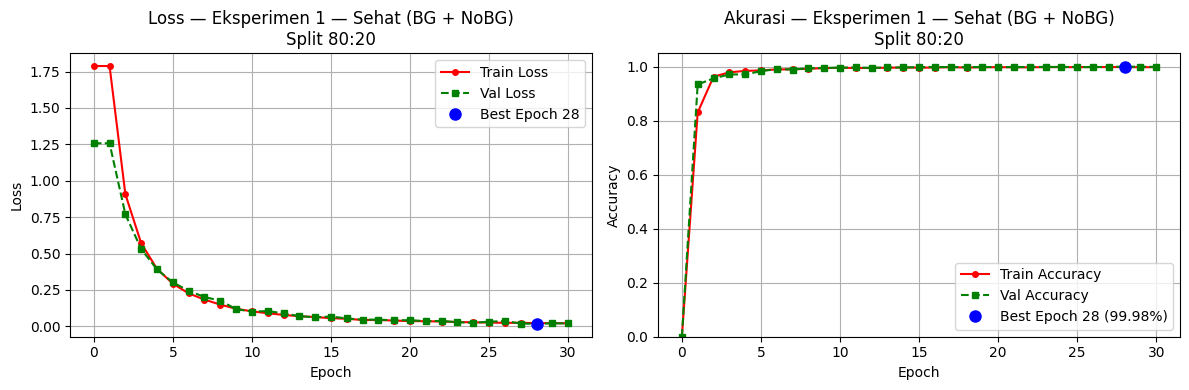

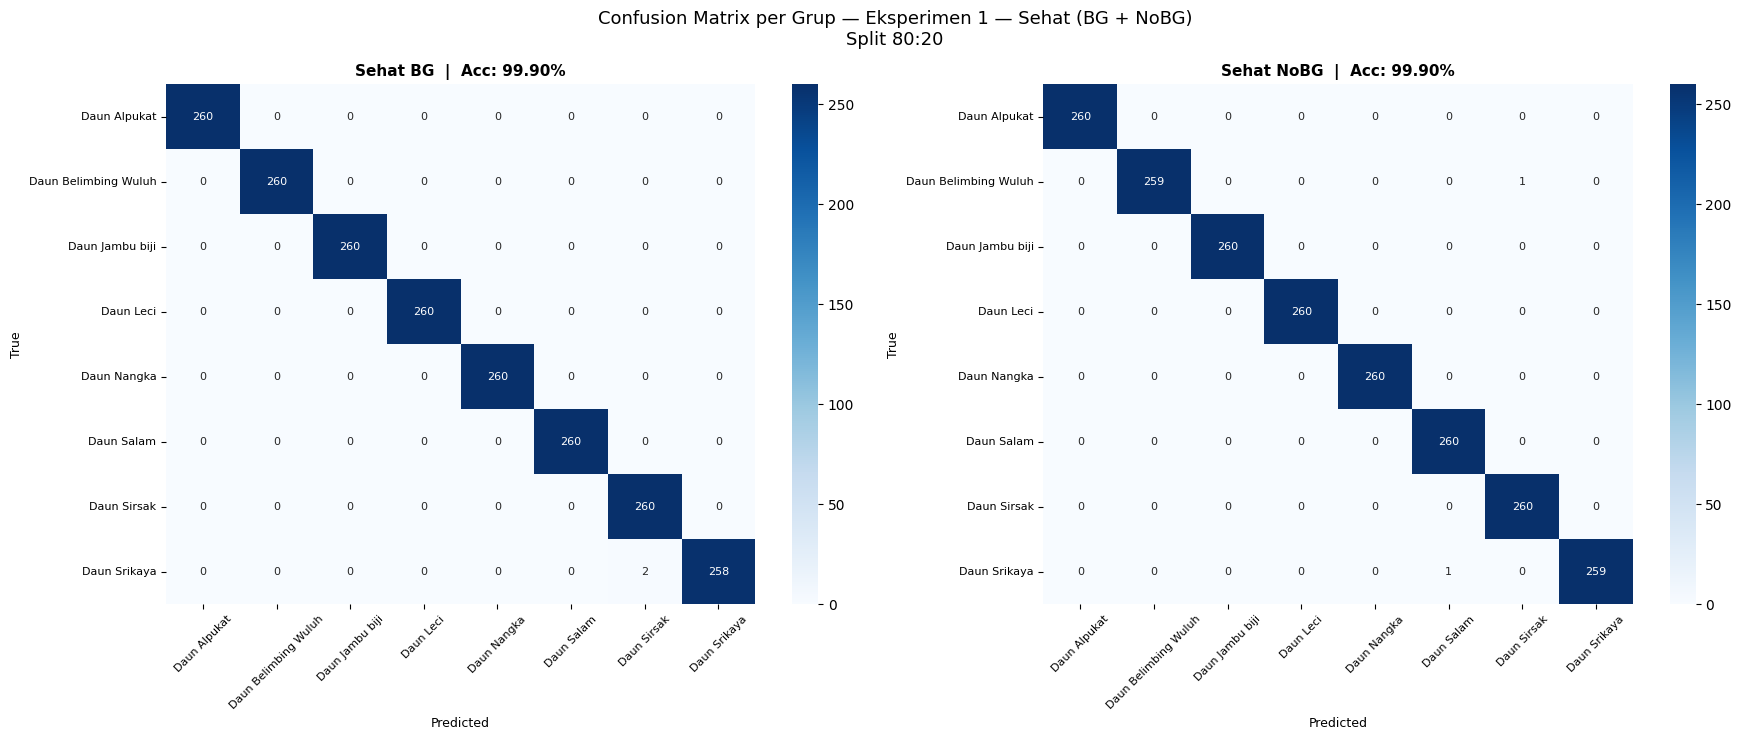

  Saved -> results_exp1_80.json

EKSPERIMEN 1 — SEHAT (BG + NOBG) | Split 70:30
Kelas: 16 | Train: 14560 | Val: 6240
  Epoch 1/30  train_loss=1.8627  train_acc=0.8217  val_loss=1.3386  val_acc=0.9192
  Epoch 2/30  train_loss=0.9983  train_acc=0.9620  val_loss=0.8433  val_acc=0.9439
  Epoch 3/30  train_loss=0.6433  train_acc=0.9743  val_loss=0.5890  val_acc=0.9649
  Epoch 4/30  train_loss=0.4615  train_acc=0.9791  val_loss=0.3947  val_acc=0.9829
  Epoch 5/30  train_loss=0.3381  train_acc=0.9865  val_loss=0.3520  val_acc=0.9793
  Epoch 6/30  train_loss=0.2672  train_acc=0.9883  val_loss=0.2690  val_acc=0.9857
  Epoch 7/30  train_loss=0.2160  train_acc=0.9900  val_loss=0.2357  val_acc=0.9889
  Epoch 8/30  train_loss=0.1773  train_acc=0.9919  val_loss=0.1918  val_acc=0.9897
  Epoch 9/30  train_loss=0.1472  train_acc=0.9922  val_loss=0.1604  val_acc=0.9934
  Epoch 10/30  train_loss=0.1231  train_acc=0.9938  val_loss=0.1393  val_acc=0.9917
  Epoch 11/30  train_loss=0.1109  train_acc=0.9942  

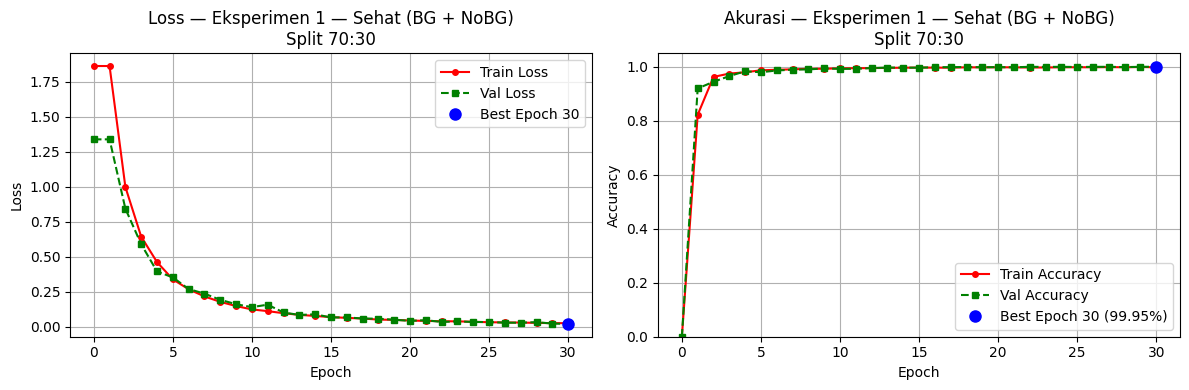

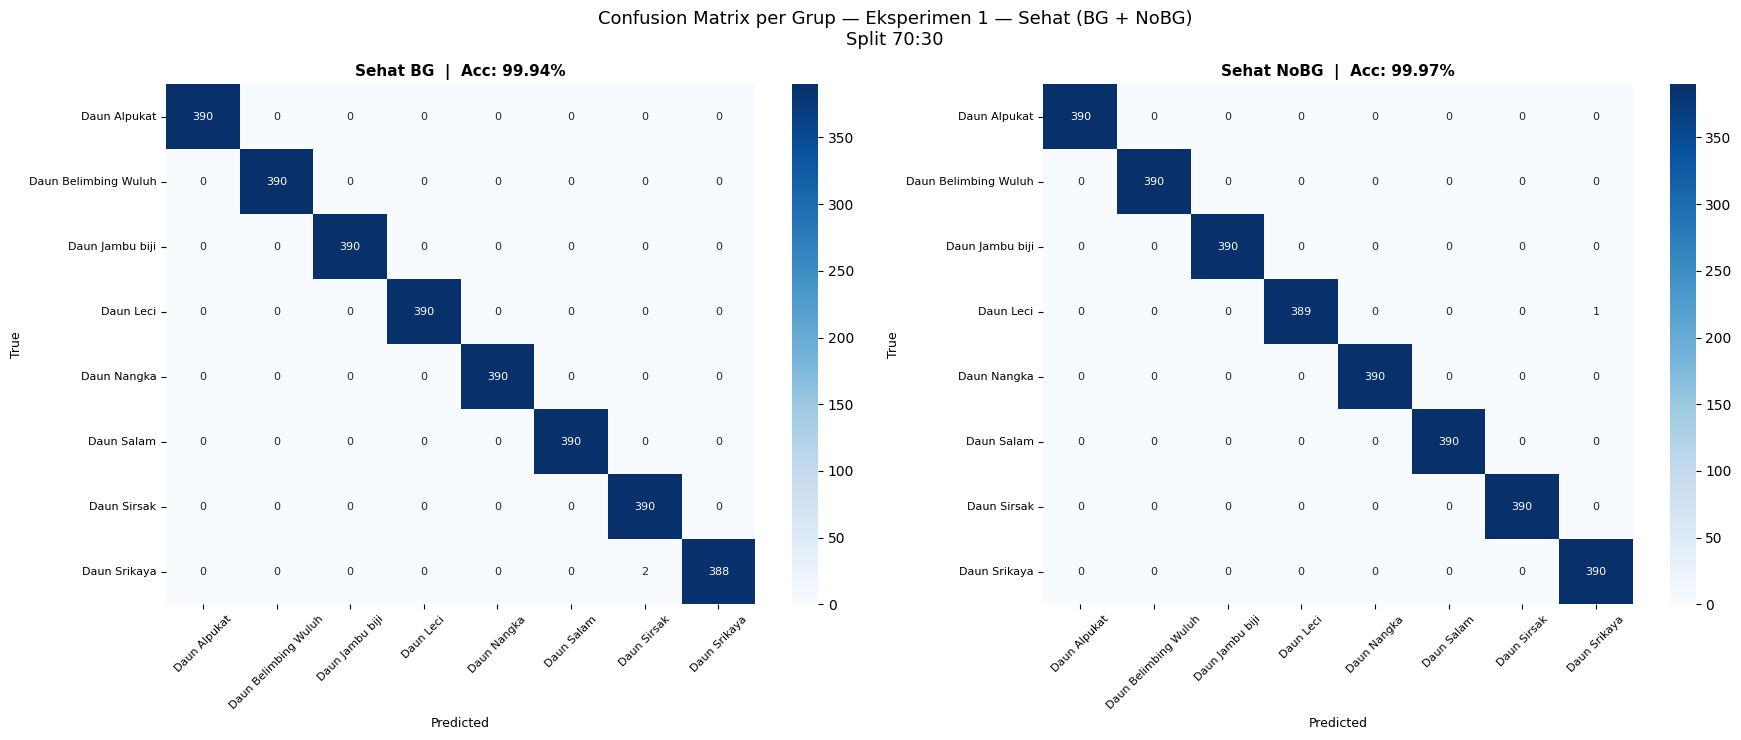

  Saved -> results_exp1_70.json


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate(
    exp_tag: str,
    exp_label: str,
    include_rusak: bool,
    split_ratio: float,
):
    test_ratio = round(1.0 - split_ratio, 10)
    train_pct  = round(split_ratio * 100)
    test_pct   = 100 - train_pct
    label_str  = f"{train_pct}:{test_pct}"

    full_ds     = CombinedTaggedDataset(FINAL_NOBG, FINAL_BG, include_rusak=include_rusak)
    class_names = full_ds.classes
    num_classes = len(class_names)
    all_labels  = np.array([lbl for _, lbl in full_ds.samples])

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_idx, val_idx = next(splitter.split(np.zeros(len(all_labels)), all_labels))

    train_loader = DataLoader(
        TransformWrapper(Subset(full_ds, train_idx), transform_train),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )
    val_loader = DataLoader(
        TransformWrapper(Subset(full_ds, val_idx), transform_val),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    print(f"\n{'='*60}")
    print(f"{exp_label.upper()} | Split {label_str}")
    print(f"Kelas: {num_classes} | Train: {len(train_idx)} | Val: {len(val_idx)}")

    model = models.shufflenet_v2_x1_0(
        weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    )
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

    history = []
    start   = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss  += loss.item()
            _, preds       = torch.max(out, 1)
            train_correct += (preds == y).sum().item()
            train_total   += y.size(0)
        avg_loss  = running_loss / len(train_loader)
        train_acc = train_correct / train_total

        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out      = model(x)
                val_loss += criterion(out, y).item()
                _, preds  = torch.max(out, 1)
                correct  += (preds == y).sum().item()
                total    += y.size(0)
        val_acc      = correct / total
        avg_val_loss = val_loss / len(val_loader)

        history.append({
            "epoch":      epoch + 1,
            "train_loss": round(avg_loss, 4),
            "train_acc":  round(train_acc, 4),
            "val_loss":   round(avg_val_loss, 4),
            "val_acc":    round(val_acc, 4),
        })
        print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={avg_loss:.4f}  train_acc={train_acc:.4f}"
              f"  val_loss={avg_val_loss:.4f}  val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"  Selesai dalam {int(elapsed//60)}m {int(elapsed%60)}s")

    # ── Evaluasi akhir ────────────────────────────────────────────────────────
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            _, preds = torch.max(model(x.to(DEVICE)), 1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    print(f"\n  {'Metric':<12} {'Score':>8}")
    print(f"  {'-'*22}")
    print(f"  {'Accuracy':<12} {acc:>8.4f}")
    print(f"  {'Precision':<12} {prec:>8.4f}")
    print(f"  {'Recall':<12} {rec:>8.4f}")
    print(f"  {'F1-Score':<12} {f1:>8.4f}")

    best = max(history, key=lambda h: h["val_acc"])

    # ── Plot loss & akurasi ───────────────────────────────────────────────────
    ep_plot         = [0] + [h["epoch"]      for h in history]
    train_loss_plot = [history[0]["train_loss"]] + [h["train_loss"] for h in history]
    val_loss_plot   = [history[0]["val_loss"]]   + [h["val_loss"]   for h in history]
    train_acc_plot  = [0] + [h["train_acc"] for h in history]
    val_acc_plot    = [0] + [h["val_acc"]   for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ep_plot, train_loss_plot, "r-o",  markersize=4, label="Train Loss")
    ax1.plot(ep_plot, val_loss_plot,   "g--s", markersize=4, label="Val Loss")
    ax1.plot(best["epoch"], best["val_loss"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']}")
    ax1.set_title(f"Loss — {exp_label}\nSplit {label_str}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(ep_plot, train_acc_plot, "r-o",  markersize=4, label="Train Accuracy")
    ax2.plot(ep_plot, val_acc_plot,   "g--s", markersize=4, label="Val Accuracy")
    ax2.plot(best["epoch"], best["val_acc"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']} ({best['val_acc']:.2%})")
    ax2.set_title(f"Akurasi — {exp_label}\nSplit {label_str}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"plot_{exp_tag}_{train_pct}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # ── Confusion matrix terpisah per grup ───────────────────────────────────
    plot_split_cm(y_true, y_pred, class_names,
                  exp_tag, train_pct, exp_label, label_str)

    # ── Simpan model & JSON (UTF-8) ───────────────────────────────────────────
    torch.save(model.state_dict(), MODEL_DIR / f"shufflenet_{exp_tag}_{train_pct}.pth")
    json_path = RESULT_DIR / f"results_{exp_tag}_{train_pct}.json"
    json_path.write_text(json.dumps({
        "experiment":            exp_label,
        "tag":                   exp_tag,
        "split":                 label_str,
        "dataset_nobg":          str(FINAL_NOBG),
        "dataset_bg":            str(FINAL_BG),
        "include_rusak":         include_rusak,
        "num_classes":           num_classes,
        "class_names":           class_names,
        "epochs":                EPOCHS,
        "training_time_sec":     round(elapsed, 2),
        "accuracy":              round(acc, 4),
        "precision_weighted":    round(prec, 4),
        "recall_weighted":       round(rec, 4),
        "f1_weighted":           round(f1, 4),
        "best_epoch":            best["epoch"],
        "best_val_accuracy":     best["val_acc"],
        "final_train_accuracy":  history[-1]["train_acc"],
        "final_val_accuracy":    history[-1]["val_acc"],
        "classification_report": report,
        "training_history":      history,
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"  Saved -> {json_path.name}")


# Jalankan Eksperimen 1 (sehat saja)
for ratio in [0.8, 0.7]:
    train_and_evaluate(
        exp_tag="exp1",
        exp_label="Eksperimen 1 — Sehat (BG + NoBG)",
        include_rusak=False,
        split_ratio=ratio,
    )


## 6. Eksperimen 2 — Gabungan BG + NoBG (Semua Kondisi: Sehat + Rusak)

Menggabungkan dataset `data/final` (NoBG) dan `data/final bg` (BG).
**Semua kelas dilatih**, termasuk daun rusak.
Nama kelas: *"Daun X BG"*, *"Daun X NoBG"*, *"Daun X Rusak BG"*, *"Daun X Rusak NoBG"* → **32 kelas**.
Confusion matrix menampilkan label rusak secara terpisah berdasarkan kondisi background.


EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 80:20
Kelas: 32 | Train: 33280 | Val: 8320
  Epoch 1/30  train_loss=2.0293  train_acc=0.8201  val_loss=1.3552  val_acc=0.9076
  Epoch 2/30  train_loss=0.9078  train_acc=0.9571  val_loss=0.8046  val_acc=0.9570
  Epoch 3/30  train_loss=0.5356  train_acc=0.9747  val_loss=0.5473  val_acc=0.9605
  Epoch 4/30  train_loss=0.3586  train_acc=0.9813  val_loss=0.3592  val_acc=0.9797
  Epoch 5/30  train_loss=0.2621  train_acc=0.9852  val_loss=0.2784  val_acc=0.9859
  Epoch 6/30  train_loss=0.2000  train_acc=0.9880  val_loss=0.2450  val_acc=0.9840
  Epoch 7/30  train_loss=0.1579  train_acc=0.9902  val_loss=0.1957  val_acc=0.9904
  Epoch 8/30  train_loss=0.1307  train_acc=0.9909  val_loss=0.1502  val_acc=0.9911
  Epoch 9/30  train_loss=0.1095  train_acc=0.9926  val_loss=0.1301  val_acc=0.9947
  Epoch 10/30  train_loss=0.0945  train_acc=0.9928  val_loss=0.1069  val_acc=0.9956
  Epoch 11/30  train_loss=0.0841  train_acc=0.9935  val_loss=0.1191 

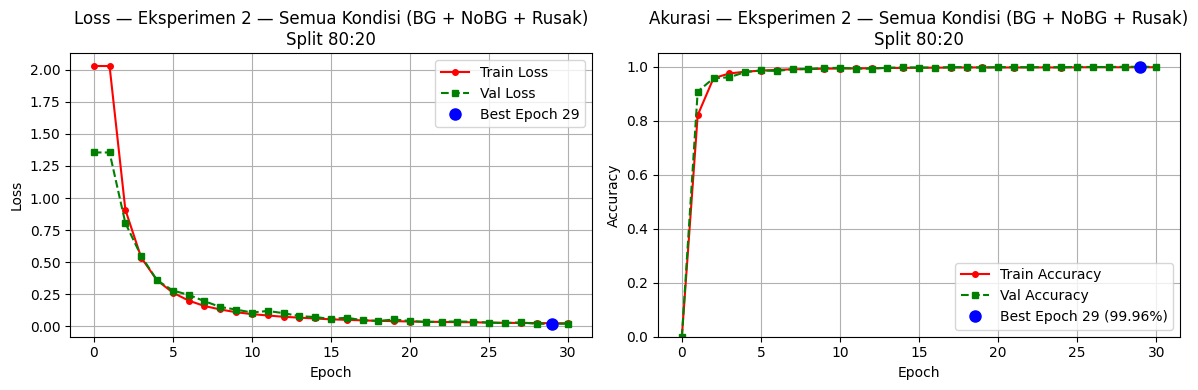

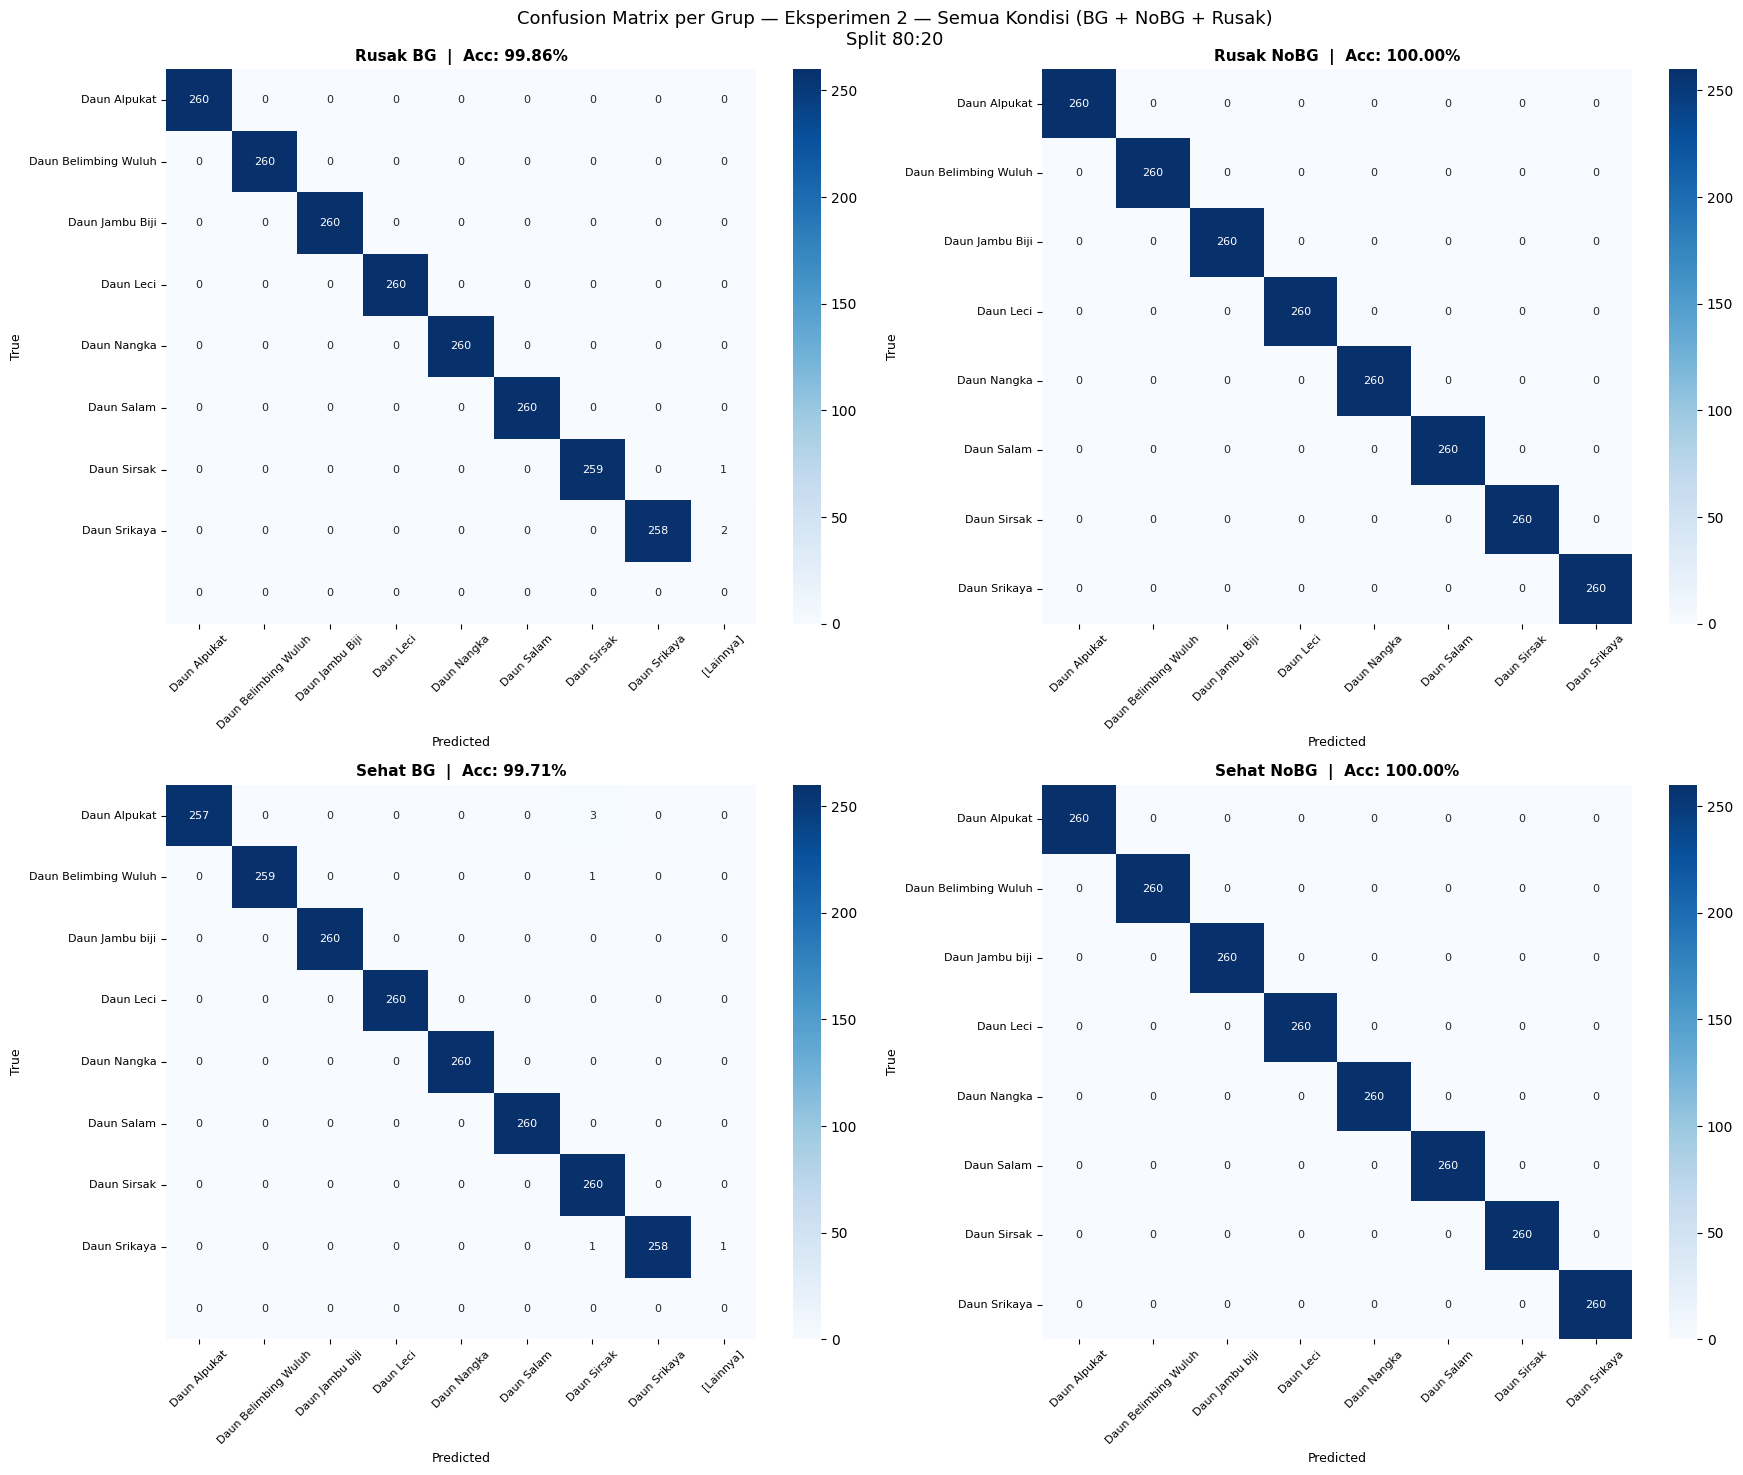

  Saved -> results_exp2_80.json

EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 70:30
Kelas: 32 | Train: 29120 | Val: 12480
  Epoch 1/30  train_loss=2.1304  train_acc=0.7926  val_loss=1.4329  val_acc=0.9092
  Epoch 2/30  train_loss=1.0230  train_acc=0.9529  val_loss=0.8660  val_acc=0.9292
  Epoch 3/30  train_loss=0.6151  train_acc=0.9715  val_loss=0.6146  val_acc=0.9573
  Epoch 4/30  train_loss=0.4208  train_acc=0.9803  val_loss=0.4623  val_acc=0.9709
  Epoch 5/30  train_loss=0.3071  train_acc=0.9833  val_loss=0.3150  val_acc=0.9861
  Epoch 6/30  train_loss=0.2355  train_acc=0.9871  val_loss=0.2863  val_acc=0.9841
  Epoch 7/30  train_loss=0.1912  train_acc=0.9885  val_loss=0.2035  val_acc=0.9885
  Epoch 8/30  train_loss=0.1561  train_acc=0.9899  val_loss=0.1769  val_acc=0.9906
  Epoch 9/30  train_loss=0.1329  train_acc=0.9916  val_loss=0.1754  val_acc=0.9893
  Epoch 10/30  train_loss=0.1134  train_acc=0.9918  val_loss=0.1391  val_acc=0.9925
  Epoch 11/30  train_loss=0.0982  t

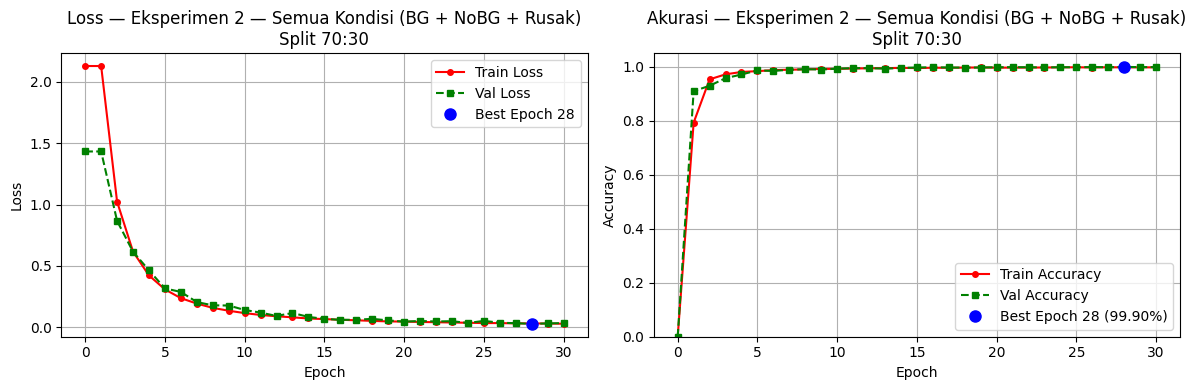

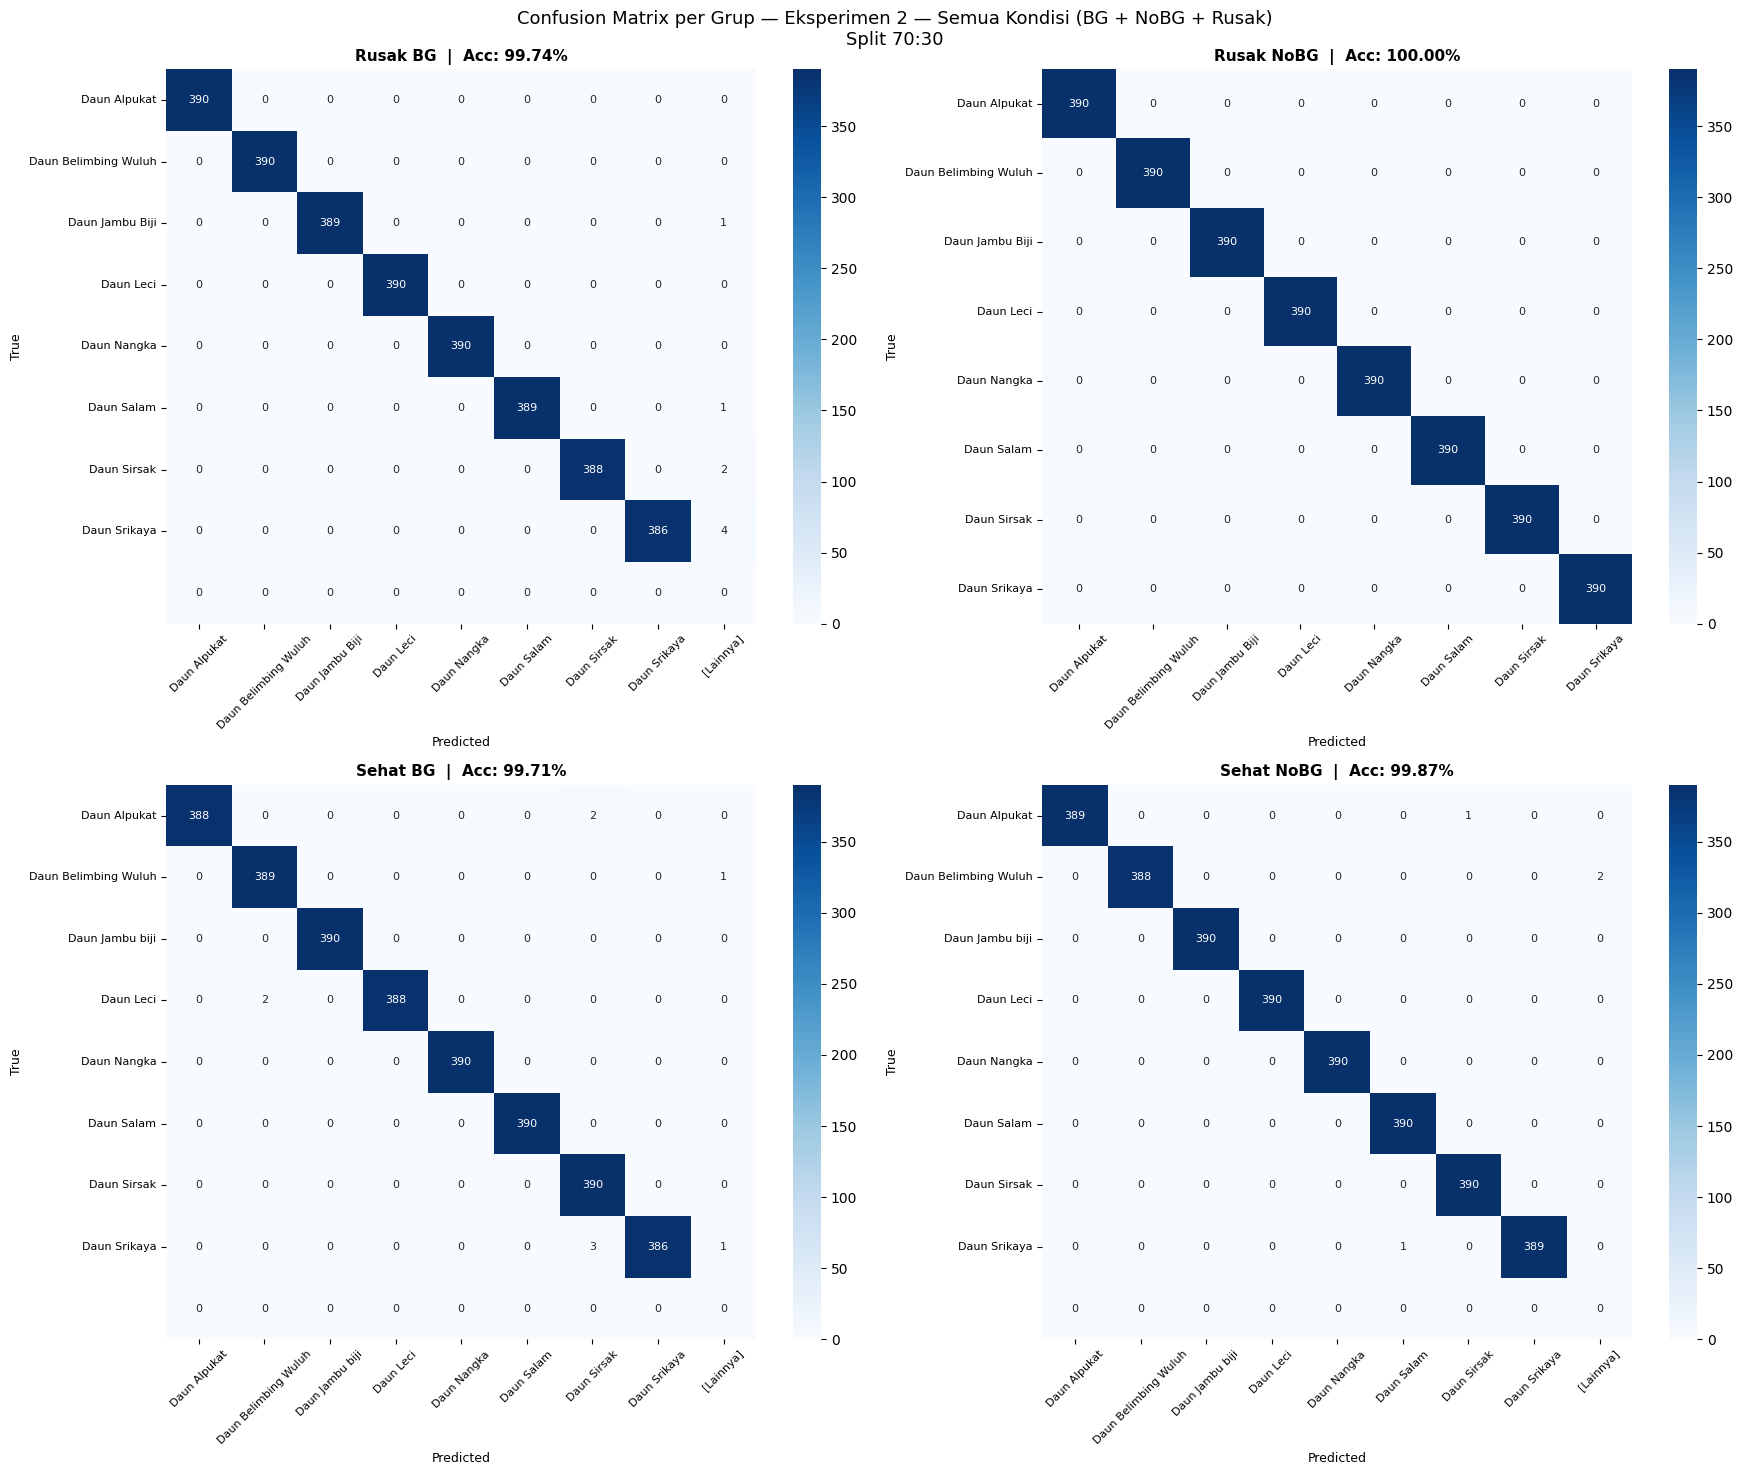

  Saved -> results_exp2_70.json


In [9]:
# Jalankan Eksperimen 2 (semua kondisi: sehat + rusak)
for ratio in [0.8, 0.7]:
    train_and_evaluate(
        exp_tag="exp2",
        exp_label="Eksperimen 2 — Semua Kondisi (BG + NoBG + Rusak)",
        include_rusak=True,
        split_ratio=ratio,
    )

## 7. Ringkasan Hasil

In [10]:
print("=== MODEL FILES ===")
for f in sorted(MODEL_DIR.glob("*.pth")):
    print(f"  {f.name}")

print("\n=== RESULT JSON ===")
for f in sorted(RESULT_DIR.glob("*.json")):
    try:
        text = f.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = f.read_text(encoding="cp1252")
    data = json.loads(text)
    acc  = data.get("final_val_accuracy", data.get("best_val_accuracy", "N/A"))
    tag  = data.get("tag", f.stem)
    print(f"  {f.name:<45} val_acc={acc}  [{tag}]")

print("\n=== PLOTS ===")
for f in sorted(RESULT_DIR.glob("*.png")):
    print(f"  {f.name}")


=== MODEL FILES ===
  shufflenet_bg_70.pth
  shufflenet_bg_80.pth
  shufflenet_condition.pth
  shufflenet_condition_70.pth
  shufflenet_condition_80.pth
  shufflenet_exp1_70.pth
  shufflenet_exp1_80.pth
  shufflenet_exp2_70.pth
  shufflenet_exp2_80.pth
  shufflenet_nobg_70.pth
  shufflenet_nobg_80.pth

=== RESULT JSON ===
  results_exp1_70.json                          val_acc=0.9995  [exp1]
  results_exp1_80.json                          val_acc=0.999  [exp1]
  results_exp2_70.json                          val_acc=0.9983  [exp2]
  results_exp2_80.json                          val_acc=0.9989  [exp2]

=== PLOTS ===
  cm_split_exp1_70.png
  cm_split_exp1_80.png
  cm_split_exp2_70.png
  cm_split_exp2_80.png
  plot_exp1_70.png
  plot_exp1_80.png
  plot_exp2_70.png
  plot_exp2_80.png
